# Can We Learn the Learning Rate? Hypergradient Descent

**EPFL OptML Mini-Project — Spring 2026**


## Notebook set-up

In [ ]:
from IPython.display import Javascript, display

display(Javascript('''
  console.log("[Anti-idle] Démarré — clic simulé toutes les 60 secondes");
  if (window._antiIdleInterval) clearInterval(window._antiIdleInterval);
  window._antiIdleInterval = setInterval(() => {
    const btn = document.querySelector("colab-connect-button");
    if (btn) btn.click();
    console.log("[Anti-idle] ping " + new Date().toLocaleTimeString());
  }, 60000);
'''))
print("Anti-idle actived")

In [ ]:
import os, json, torch


SAVE_DIR = '/kaggle/working/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs('figures', exist_ok=True)

RESULTS_PATH     = os.path.join(SAVE_DIR, 'all_results.json')
SENSITIVITY_PATH = os.path.join(SAVE_DIR, 'sensitivity_results.json')
METALR_PATH      = os.path.join(SAVE_DIR, 'meta_lr_results.json')
CKPT_DIR         = os.path.join(SAVE_DIR, 'model_ckpts')
os.makedirs(CKPT_DIR, exist_ok=True)

RESTORE_FROM = None

if RESTORE_FROM and os.path.exists(RESTORE_FROM):
    import shutil
    for f in os.listdir(RESTORE_FROM):
        src_path = os.path.join(RESTORE_FROM, f)
        dst_path = os.path.join(SAVE_DIR, f)
        shutil.copy2(src_path, dst_path)
    ckpt_src = os.path.join(RESTORE_FROM, 'model_ckpts')
    if os.path.exists(ckpt_src):
        for f in os.listdir(ckpt_src):
            shutil.copy2(os.path.join(ckpt_src, f), os.path.join(CKPT_DIR, f))
    print(f"Files restaured from : {RESTORE_FROM}")
else:
    print(" No restaureation — new session")

print(f"\n Working folder : {SAVE_DIR}")
print(f"   Existing files : {os.listdir(SAVE_DIR)}")

def save_experiment_result(name, result, results_dict, path):
    """Backupof result in a dict and the disk"""
    results_dict[name] = result
    serializable = {}
    for k, v in results_dict.items():
        serializable[k] = {
            'train_loss': v['train_loss'],
            'train_acc':  v['train_acc'],
            'val_loss':   v['val_loss'],
            'val_acc':    v['val_acc'],
            'test_acc':   float(v['test_acc']) if v['test_acc'] is not None else None,
            'lr_history': [float(x) for x in v['lr_history']],
            'name':       v['name'],
        }
    with open(path, 'w') as f:
        json.dump(serializable, f, indent=2)
    print(f"   Saved : {os.path.basename(path)}")


def load_results_if_exist(path):
    """Load a JSON file if exist"""
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        print(f" Results loaded : {os.path.basename(path)} ({len(data)} expériences)")
        return data
    return {}


def save_model_checkpoint(model, optimizer, epoch, name, extra=None):
    """Save a checkpoint model + optimizer"""
    safe_name = name.replace(' ', '_').replace('=', '').replace('.', 'p')
    path = os.path.join(CKPT_DIR, f'{safe_name}_epoch{epoch}.pt')
    payload = {
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
    }
    if extra:
        payload.update(extra)
    torch.save(payload, path)
    return path


def load_model_checkpoint(model, optimizer, name):
    """Load the most recent checkpoint for a given experience."""
    safe_name = name.replace(' ', '_').replace('=', '').replace('.', 'p')
    pattern   = f'{safe_name}_epoch'
    candidates = [f for f in os.listdir(CKPT_DIR) if f.startswith(pattern) and f.endswith('.pt')]
    if not candidates:
        return 0, None
    latest = sorted(candidates, key=lambda f: int(f.replace(pattern,'').replace('.pt','')))[-1]
    ckpt   = torch.load(os.path.join(CKPT_DIR, latest), map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    print(f"  Checkpoint loaded : {latest} (restart at epoch {ckpt['epoch']+1})")
    return ckpt['epoch'] + 1, ckpt


print("\n Utils checkpoint defined.")


In [ ]:
def print_progress():
    results_files = {
        'Expériences principales': RESULTS_PATH,
        'Sensibilité LR':         SENSITIVITY_PATH,
        'Ablation meta-LR':       METALR_PATH,
    }
    print("\n Pregressions saved on the drive")
    print("─" * 50)
    for label, path in results_files.items():
        if os.path.exists(path):
            import json
            data = json.load(open(path))
            print(f"  {label}: {list(data.keys())}")
        else:
            print(f"  {label}: pas encore commencé")

    print("\n🗂  Model checkpoint :")
    ckpts = os.listdir(CKPT_DIR) if os.path.exists(CKPT_DIR) else []
    if ckpts:
        for c in sorted(ckpts):
            print(f"  -> {c}")
    else:
        print("  (No checkpoint found)")
    print("─" * 50)

print_progress()

# Imports and global configuration

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from tqdm import tqdm
import copy
import random
import os

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

# Plot style
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

# Output directory for saving plots
os.makedirs("figures", exist_ok=True)

Using device: cuda
PyTorch version: 2.11.0+cu128


# Hypergradient Descent

## Global hyperparameters

All experimental hyperparameters are defined here in a single dictionary, therefore we can modify here at a global level

In [ ]:
CONFIG = {
    # Data
    "dataset": "CIFAR10",
    "batch_size": 128,
    "num_workers": 2,
    "num_epochs":100,
    # Hypergradient SGD
    "hgd_lr_init":0.1,
    "hgd_meta_lr":1e-6,
    "hgd_momentum":0.9,
    "hgd_lr_clip":(1e-6, 1.0),
    # Fixed LR SGD baselines (several values to show sensitivity)
    "fixed_lrs":[0.001, 0.01, 0.1, 0.5],
    "fixed_momentum":0.9,
    # Cosine decay SGD baseline
    "cosine_lr":0.1,
    "cosine_momentum":0.9,
    # Adam baseline
    "adam_lr":1e-3,
    "adam_betas":(0.9, 0.999),
    "adam_eps":1e-8,
    # Weight decay (L2 regularization)
    "weight_decay":5e-4,
}
print("Experiment configuration:")
for k, v in CONFIG.items():
    print(f"  {k:25s}: {v}")

Experiment configuration:
  dataset                  : CIFAR10
  batch_size               : 128
  num_workers              : 2
  num_epochs               : 100
  hgd_lr_init              : 0.1
  hgd_meta_lr              : 1e-06
  hgd_momentum             : 0.9
  hgd_lr_clip              : (1e-06, 1.0)
  fixed_lrs                : [0.001, 0.01, 0.1, 0.5]
  fixed_momentum           : 0.9
  cosine_lr                : 0.1
  cosine_momentum          : 0.9
  adam_lr                  : 0.001
  adam_betas               : (0.9, 0.999)
  adam_eps                 : 1e-08
  weight_decay             : 0.0005


# Dataset loading

In [ ]:
# Transforms
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Download datasets
full_train = torchvision.datasets.CIFAR10(root="./data", train=True,
                                           download=True, transform=train_transform)
test_set   = torchvision.datasets.CIFAR10(root="./data", train=False,
                                           download=True, transform=test_transform)

# Train / validation split
val_size   = 5000
train_size = len(full_train) - val_size
generator  = torch.Generator().manual_seed(SEED)
train_set, val_set = torch.utils.data.random_split(
    full_train, [train_size, val_size], generator=generator
)

# DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=CONFIG["batch_size"],
    shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=torch.cuda.is_available()
)
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=256, shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=torch.cuda.is_available()
)
test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=256, shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=torch.cuda.is_available()
)

print(f"Train set   : {len(train_set):,} samples")
print(f"Val set     : {len(val_set):,} samples")
print(f"Test set    : {len(test_set):,} samples")
print(f"Batches/epoch: {len(train_loader)}")

100%|██████████| 170M/170M [00:03<00:00, 49.2MB/s] 


Train set   : 45,000 samples
Val set     : 5,000 samples
Test set    : 10,000 samples
Batches/epoch: 352


# Model definition

In [ ]:
def get_model(seed=SEED):
    torch.manual_seed(seed)
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.to(DEVICE)

# Sanity check
_m = get_model()
_dummy = torch.zeros(2, 3, 32, 32).to(DEVICE)
_out   = _m(_dummy)
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Output shape : {_out.shape}  (expected: [2, 10])")
print(f"# parameters : {n_params:,}")
del _m, _dummy, _out

Output shape : torch.Size([2, 10])  (expected: [2, 10])
# parameters : 11,173,962


# Hypergradient SGD implementation

In [ ]:
class SGDHD(torch.optim.Optimizer):
    """
    SGD with Hypergradient Descent (SGD-HD).

    Adapts the global learning rate online by computing the dot product
    between the current and previous gradient (the 'hypergradient').

    Reference:
        Baydin et al., "Online Learning Rate Adaptation with Hypergradient
        Descent", ICLR 2018. https://arxiv.org/abs/1703.04782

    Args:
        params:     Model parameters (same as any optimizer).
        lr:         Initial learning rate α₀.
        meta_lr:    Meta learning rate β (step size for the LR update).
        momentum:   SGD momentum coefficient.
        weight_decay: L2 regularization coefficient.
        lr_clip:    (min, max) bounds for the adapted learning rate.
    """

    def __init__(self, params, lr=0.1, meta_lr=1e-6, momentum=0.9,
                 weight_decay=0.0, lr_clip=(1e-6, 1.0)):
        defaults = dict(lr=lr, meta_lr=meta_lr, momentum=momentum,
                        weight_decay=weight_decay, lr_clip=lr_clip)
        super().__init__(params, defaults)

        self.current_lr = lr
        self.lr_history = [lr]

    @torch.no_grad()
    def step(self, closure=None):
        """
        Performs one optimization step.

        The hypergradient is computed as the negative dot product of the current
        gradient g_t with the cached previous gradient g_{t-1}.

        Steps:
          1. Accumulate the hypergradient across all parameter tensors.
          2. Update the global learning rate using the hypergradient.
          3. Update each parameter using SGD with momentum at the new LR.
          4. Cache the current gradient as the 'previous gradient' for next step.
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            meta_lr    = group["meta_lr"]
            momentum   = group["momentum"]
            wd         = group["weight_decay"]
            lr_min, lr_max = group["lr_clip"]

            # Step 1: Compute the hypergradient
            hypergradient = 0.0
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]

                if len(state) == 0:
                    state["prev_grad"] = torch.zeros_like(p.data)
                    state["momentum_buf"] = torch.zeros_like(p.data)

                g_t   = p.grad.data
                g_prev = state["prev_grad"]
                if wd != 0:
                    g_t = g_t.add(p.data, alpha=wd)

                hypergradient += (-g_t * g_prev).sum().item()

            # Step 2: Update the global learning rate
            new_lr = self.current_lr - meta_lr * hypergradient
            new_lr = float(np.clip(new_lr, lr_min, lr_max))
            self.current_lr = new_lr
            self.lr_history.append(new_lr)

            # Step 3 & 4: Parameter update with SGD+momentum at new LR
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]
                g_t   = p.grad.data

                if wd != 0:
                    g_t = g_t.add(p.data, alpha=wd)

                # Momentum update
                buf = state["momentum_buf"]
                buf.mul_(momentum).add_(g_t)

                # Parameter update
                p.data.add_(buf, alpha=-new_lr)

                state["prev_grad"].copy_(g_t)

        return loss

print("SGDHD optimizer defined successfully.")

SGDHD optimizer defined successfully.


# Training and evaluation utils

Helper functions used for all experiments:
- `train_epoch`: runs one epoch of training, returns average loss and accuracy
- `evaluate`: evaluates the model on a DataLoader, returns loss and accuracy
- `run_experiment`: full training loop with logging, returns a results dictionary

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    """
    Runs one full epoch over the training data.

    Returns:
        avg_loss (float): mean cross-entropy loss over the epoch
        accuracy (float): fraction of correctly classified examples
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total   += inputs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """
    Evaluates the model on a DataLoader without computing gradients.

    Returns:
        avg_loss (float): mean cross-entropy loss
        accuracy (float): fraction of correct predictions
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)
        loss    = criterion(outputs, targets)

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total   += inputs.size(0)

    return total_loss / total, correct / total


def run_experiment(name, optimizer_fn, num_epochs=None, verbose=True):
    """
    Runs a full training experiment with a given optimizer.

    Args:
        name (str):         Label for this experiment (used in plots).
        optimizer_fn:       A callable (model) -> optimizer. Takes a freshly
                            initialized model and returns an optimizer bound to it.
        num_epochs (int):   Override CONFIG["num_epochs"] if provided.
        verbose (bool):     Print per-epoch summary.

    Returns:
        dict with keys:
          'name':        experiment label
          'train_loss':  list of train losses per epoch
          'train_acc':   list of train accuracies per epoch
          'val_loss':    list of val losses per epoch
          'val_acc':     list of val accuracies per epoch
          'test_acc':    final test accuracy (scalar)
          'lr_history':  list of LR values (step-level, for HGD only)
    """
    epochs = num_epochs or CONFIG["num_epochs"]

    model     = get_model(seed=SEED)
    optimizer = optimizer_fn(model)
    criterion = nn.CrossEntropyLoss()

    results = {
        "name":       name,
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "test_acc":   None,
        "lr_history": [],
    }

    start_epoch, ckpt = load_model_checkpoint(model, optimizer, name)
    if start_epoch > 0 and ckpt is not None:
        results["train_loss"] = ckpt.get("train_loss", [])
        results["train_acc"]  = ckpt.get("train_acc",  [])
        results["val_loss"]   = ckpt.get("val_loss",   [])
        results["val_acc"]    = ckpt.get("val_acc",    [])
        results["lr_history"] = ckpt.get("lr_history", [])
        if hasattr(optimizer, "current_lr") and "current_lr" in ckpt:
            optimizer.current_lr = ckpt["current_lr"]
            optimizer.lr_history = results["lr_history"].copy()
    else:
        start_epoch = 0

    pbar = tqdm(range(start_epoch + 1, epochs + 1), desc=name, leave=True)
    for epoch in pbar:
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        results["train_loss"].append(tr_loss)
        results["train_acc"].append(tr_acc)
        results["val_loss"].append(vl_loss)
        results["val_acc"].append(vl_acc)

        if hasattr(optimizer, "current_lr"):
            results["lr_history"] = optimizer.lr_history.copy()
            epoch_lr = optimizer.current_lr
        else:
            epoch_lr = optimizer.param_groups[0]["lr"]
            results["lr_history"].append(epoch_lr)

        if verbose:
            pbar.set_postfix(
                tr_loss=f"{tr_loss:.3f}",
                vl_acc=f"{vl_acc*100:.1f}%",
                lr=f"{epoch_lr:.2e}"
            )
        if epoch % 5 == 0 or epoch == epochs:
            extra = {
                "train_loss": results["train_loss"],
                "train_acc":  results["train_acc"],
                "val_loss":   results["val_loss"],
                "val_acc":    results["val_acc"],
                "lr_history": results["lr_history"],
            }
            if hasattr(optimizer, "current_lr"):
                extra["current_lr"] = optimizer.current_lr
            save_model_checkpoint(model, optimizer, epoch, name, extra=extra)

    # Final test evaluation
    _, test_acc = evaluate(model, test_loader, criterion)
    results["test_acc"] = test_acc

    print(f"  [{name}] Final test accuracy: {test_acc*100:.2f}%")
    return results

print("Training utilities defined.")

Training utilities defined.


#  Experiment A: Hypergradient SGD vs. fixed-LR SGD

- **SGD-HD** with initial LR = 0.1 (the same as the best fixed-LR baseline)
- **SGD fixed LR** at 4 different values (0.001, 0.01, 0.1, 0.5)

In [ ]:
all_results = {}

_loaded = load_results_if_exist(RESULTS_PATH)
if _loaded:
    all_results.update(_loaded)
    print(f"♻️  Expériences déjà disponibles : {list(all_results.keys())}")

def make_sgdhd(model):
    return SGDHD(
        model.parameters(),
        lr=CONFIG["hgd_lr_init"],
        meta_lr=CONFIG["hgd_meta_lr"],
        momentum=CONFIG["hgd_momentum"],
        weight_decay=CONFIG["weight_decay"],
        lr_clip=CONFIG["hgd_lr_clip"],
    )

if "SGD-HD" not in all_results:
    res = run_experiment("SGD-HD", make_sgdhd)
    save_experiment_result("SGD-HD", res, all_results, RESULTS_PATH)
else:
    print("⏭️  SGD-HD déjà calculé, ignoré.")

for lr in CONFIG["fixed_lrs"]:
    name = f"SGD lr={lr}"
    if name in all_results:
        print(f"⏭️  {name} déjà calculé, ignoré.")
        continue

    def make_fixed_sgd(model, _lr=lr):
        return torch.optim.SGD(
            model.parameters(),
            lr=_lr,
            momentum=CONFIG["fixed_momentum"],
            weight_decay=CONFIG["weight_decay"],
        )

    res = run_experiment(name, make_fixed_sgd)
    save_experiment_result(name, res, all_results, RESULTS_PATH)

SGD-HD: 100%|██████████| 100/100 [1:18:36<00:00, 47.17s/it, lr=1.03e-01, tr_loss=0.317, vl_acc=82.6%]


  [SGD-HD] Final test accuracy: 83.70%


SGD lr=0.001: 100%|██████████| 100/100 [1:16:59<00:00, 46.19s/it, lr=1.00e-03, tr_loss=0.080, vl_acc=85.9%]


  [SGD lr=0.001] Final test accuracy: 85.83%


SGD lr=0.01: 100%|██████████| 100/100 [1:16:55<00:00, 46.15s/it, lr=1.00e-02, tr_loss=0.053, vl_acc=89.3%]


  [SGD lr=0.01] Final test accuracy: 89.55%


SGD lr=0.1:  22%|██▏       | 22/100 [16:47<59:17, 45.61s/it, lr=1.00e-01, tr_loss=0.385, vl_acc=79.5%]  

# Experiment B: Cosine decay and Adam baselines

- **SGD + cosine annealing**
- **Adam**

In [ ]:
# 3. SGD + cosine annealing
def make_cosine_sgd(model):
    opt = torch.optim.SGD(
        model.parameters(),
        lr=CONFIG["cosine_lr"],
        momentum=CONFIG["cosine_momentum"],
        weight_decay=CONFIG["weight_decay"],
    )
    return opt

def run_cosine_experiment():
    model     = get_model(seed=SEED)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=CONFIG["cosine_lr"],
        momentum=CONFIG["cosine_momentum"],
        weight_decay=CONFIG["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG["num_epochs"], eta_min=0
    )

    results = {
        "name": "SGD + cosine",
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "test_acc":   None,
        "lr_history": [],
    }

    pbar = tqdm(range(1, CONFIG["num_epochs"] + 1), desc="SGD + cosine")
    for epoch in pbar:
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        results["train_loss"].append(tr_loss)
        results["train_acc"].append(tr_acc)
        results["val_loss"].append(vl_loss)
        results["val_acc"].append(vl_acc)
        results["lr_history"].append(optimizer.param_groups[0]["lr"])
        scheduler.step()
        pbar.set_postfix(vl_acc=f"{vl_acc*100:.1f}%")

    _, test_acc = evaluate(model, test_loader, criterion)
    results["test_acc"] = test_acc
    print(f"  [SGD + cosine] Final test accuracy: {test_acc*100:.2f}%")
    return results

if "SGD + cosine" not in all_results:
    res = run_cosine_experiment()
    save_experiment_result("SGD + cosine", res, all_results, RESULTS_PATH)
else:
    print("⏭️  SGD + cosine already commputed.")

# Adam
def make_adam(model):
    return torch.optim.Adam(
        model.parameters(),
        lr=CONFIG["adam_lr"],
        betas=CONFIG["adam_betas"],
        eps=CONFIG["adam_eps"],
        weight_decay=CONFIG["weight_decay"],
    )

if "Adam" not in all_results:
    res = run_experiment("Adam", make_adam)
    save_experiment_result("Adam", res, all_results, RESULTS_PATH)
else:
    print("⏭️  Adam already computed.")

SGD + cosine: 100%|██████████| 10/10 [06:45<00:00, 40.54s/it, vl_acc=85.1%]


  [SGD + cosine] Final test accuracy: 86.08%


Adam: 100%|██████████| 10/10 [06:52<00:00, 41.21s/it, lr=1.00e-03, tr_loss=0.453, vl_acc=82.6%]


  [Adam] Final test accuracy: 83.10%


# Experiment C: LR sensitivity of SGD-HD vs. fixed SGD

In [ ]:
sensitivity_lrs = [0.001, 0.01, 0.05, 0.1, 0.5]

sensitivity_results = {}

_loaded_sens = load_results_if_exist(SENSITIVITY_PATH)
if _loaded_sens:
    sensitivity_results.update(_loaded_sens)
    print(f"  Sensitivity already available : {list(sensitivity_results.keys())}")

for lr_init in sensitivity_lrs:
    label = f"SGD-HD lr0={lr_init}"

    def make_hgd_sensitivity(model, _lr=lr_init):
        return SGDHD(
            model.parameters(),
            lr=_lr,
            meta_lr=CONFIG["hgd_meta_lr"],
            momentum=CONFIG["hgd_momentum"],
            weight_decay=CONFIG["weight_decay"],
            lr_clip=CONFIG["hgd_lr_clip"],
        )

    if label in sensitivity_results:
        print(f" {label} already computed.")
        continue
    res = run_experiment(label, make_hgd_sensitivity)
    save_experiment_result(label, res, sensitivity_results, SENSITIVITY_PATH)

print("\nSensitivity analysis complete.")

SGD-HD lr0=0.001: 100%|██████████| 10/10 [07:12<00:00, 43.25s/it, lr=7.54e-03, tr_loss=0.603, vl_acc=75.9%]


  [SGD-HD lr0=0.001] Final test accuracy: 76.26%


SGD-HD lr0=0.01: 100%|██████████| 10/10 [07:13<00:00, 43.32s/it, lr=1.41e-02, tr_loss=0.409, vl_acc=79.2%]


  [SGD-HD lr0=0.01] Final test accuracy: 79.85%


SGD-HD lr0=0.05: 100%|██████████| 10/10 [07:11<00:00, 43.14s/it, lr=5.08e-02, tr_loss=0.405, vl_acc=79.8%]


  [SGD-HD lr0=0.05] Final test accuracy: 80.43%


SGD-HD lr0=0.1: 100%|██████████| 10/10 [07:09<00:00, 42.95s/it, lr=1.00e-01, tr_loss=0.534, vl_acc=78.5%]


  [SGD-HD lr0=0.1] Final test accuracy: 79.71%


SGD-HD lr0=0.5: 100%|██████████| 10/10 [07:05<00:00, 42.51s/it, lr=5.00e-01, tr_loss=0.901, vl_acc=64.5%]


  [SGD-HD lr0=0.5] Final test accuracy: 65.51%

Sensitivity analysis complete.


# Plot: Training and validation loss curves

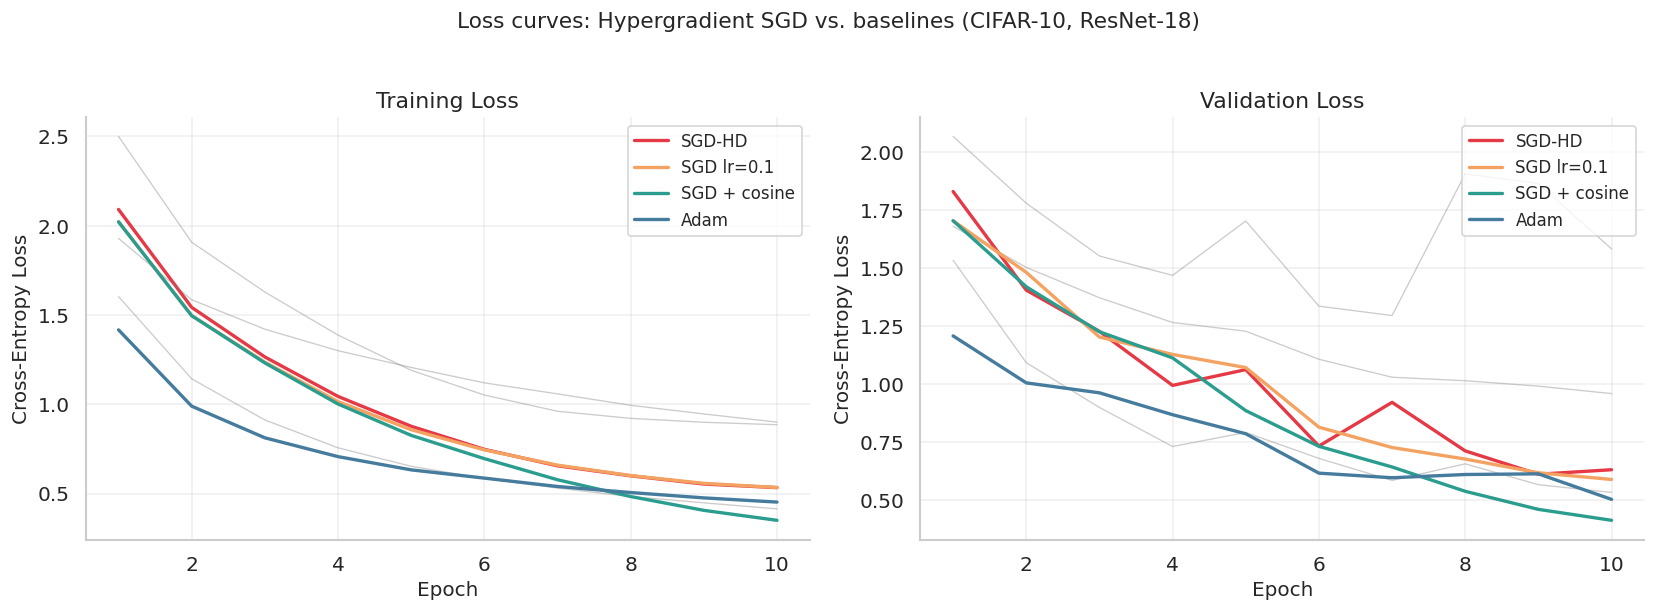

Saved: figures/fig1_loss_curves.pdf


In [ ]:
# Loss curves (train)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, CONFIG["num_epochs"] + 1)

highlight = {"SGD-HD", "SGD + cosine", "Adam", "SGD lr=0.1"}
colors    = {"SGD-HD": "#e63946", "SGD + cosine": "#2a9d8f",
             "Adam": "#457b9d",   "SGD lr=0.1": "#f4a261"}

for ax, metric, title in zip(axes,
                              ["train_loss", "val_loss"],
                              ["Training Loss", "Validation Loss"]):
    for name, res in all_results.items():
        values = res[metric]
        if name in highlight:
            ax.plot(epochs_range, values, label=name, lw=2, color=colors[name])
        else:
            ax.plot(epochs_range, values, color="gray", lw=0.8, alpha=0.4)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.set_title(title)
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

fig.suptitle("Loss curves: Hypergradient SGD vs. baselines (CIFAR-10, ResNet-18)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig1_loss_curves.pdf", bbox_inches="tight")
plt.show()
print("Saved: figures/fig1_loss_curves.pdf")

# Plot : Learned learning rate trajectory

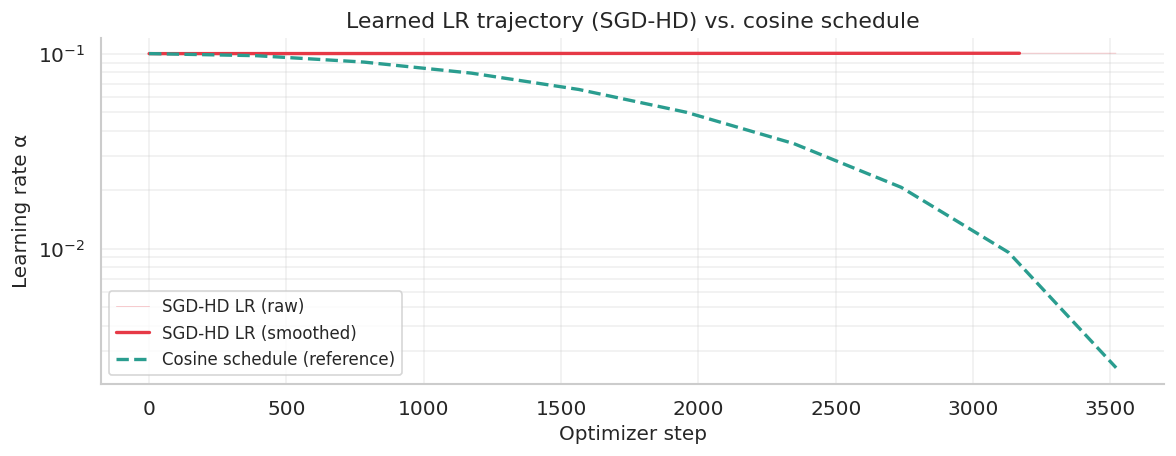

Saved: figures/fig2_lr_trajectory.pdf


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

hgd_lr = np.array(all_results["SGD-HD"]["lr_history"])
steps  = np.arange(len(hgd_lr))

ax.plot(steps, hgd_lr, color="#e63946", alpha=0.25, lw=0.6, label="SGD-HD LR (raw)")

window = max(1, len(train_loader))
if len(hgd_lr) >= window:
    kernel    = np.ones(window) / window
    smoothed  = np.convolve(hgd_lr, kernel, mode="valid")
    ax.plot(np.arange(len(smoothed)), smoothed, color="#e63946", lw=2,
            label="SGD-HD LR (smoothed)")

cosine_lr  = np.array(all_results["SGD + cosine"]["lr_history"])
steps_ep   = np.linspace(0, len(hgd_lr), len(cosine_lr))
ax.plot(steps_ep, cosine_lr, color="#2a9d8f", lw=2, linestyle="--",
        label="Cosine schedule (reference)")

ax.set_xlabel("Optimizer step")
ax.set_ylabel("Learning rate α")
ax.set_title("Learned LR trajectory (SGD-HD) vs. cosine schedule")
ax.legend()
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/fig2_lr_trajectory.pdf", bbox_inches="tight")
plt.show()
print("Saved: figures/fig2_lr_trajectory.pdf")

# Plot : Final accuracy comparison bar chart

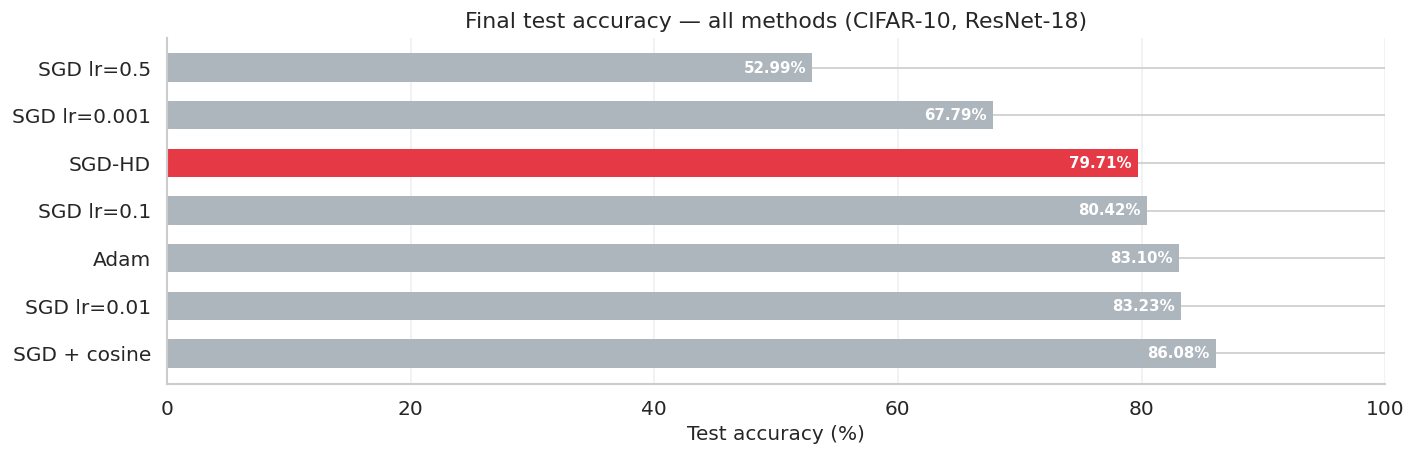

Saved: figures/fig3_accuracy_bar.pdf


In [ ]:
bar_data = sorted(
    [(name, res["test_acc"] * 100) for name, res in all_results.items()],
    key=lambda x: x[1], reverse=True
)

names_bar  = [d[0] for d in bar_data]
accs_bar   = [d[1] for d in bar_data]

bar_colors = ["#e63946" if "SGD-HD" in n else "#adb5bd" for n in names_bar]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.barh(names_bar, accs_bar, color=bar_colors, height=0.6, edgecolor="none")

for bar, acc in zip(bars, accs_bar):
    ax.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height() / 2,
            f"{acc:.2f}%", va="center", ha="right", fontsize=9,
            color="white", fontweight="bold")

ax.set_xlabel("Test accuracy (%)")
ax.set_title("Final test accuracy — all methods (CIFAR-10, ResNet-18)")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig3_accuracy_bar.pdf", bbox_inches="tight")
plt.show()
print("Saved: figures/fig3_accuracy_bar.pdf")

# Plot : LR sensitivity analysis

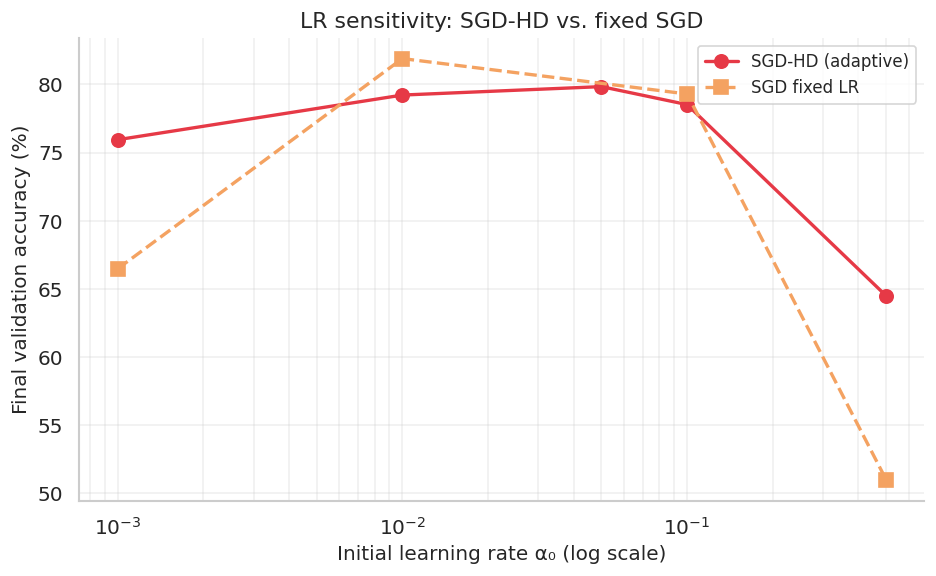

Saved: figures/fig4_lr_sensitivity.pdf


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

hgd_acc_sens   = [sensitivity_results[f"SGD-HD lr0={lr}"]["val_acc"][-1] * 100
                  for lr in sensitivity_lrs]
fixed_acc_sens = [all_results.get(f"SGD lr={lr}", {}).get("val_acc", [None])[-1]
                  for lr in sensitivity_lrs]
fixed_acc_sens_pct = [(a * 100 if a is not None else None) for a in fixed_acc_sens]

ax.plot(sensitivity_lrs, hgd_acc_sens, "o-", color="#e63946", lw=2,
        label="SGD-HD (adaptive)", markersize=8)

valid = [(lr, acc) for lr, acc in zip(sensitivity_lrs, fixed_acc_sens_pct)
         if acc is not None]
if valid:
    lrs_v, accs_v = zip(*valid)
    ax.plot(lrs_v, accs_v, "s--", color="#f4a261", lw=2,
            label="SGD fixed LR", markersize=8)

ax.set_xscale("log")
ax.set_xlabel("Initial learning rate α₀ (log scale)")
ax.set_ylabel("Final validation accuracy (%)")
ax.set_title("LR sensitivity: SGD-HD vs. fixed SGD")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/fig4_lr_sensitivity.pdf", bbox_inches="tight")
plt.show()
print("Saved: figures/fig4_lr_sensitivity.pdf")

# Plot : Convergence speed (steps to reach X% accuracy)

Method                60% acc  70% acc  75% acc  80% acc
------------------------------------------------------------
SGD-HD                       4         6         8         —
SGD + cosine                 4         6         7         8
Adam                         2         5         6        10
SGD lr=0.1                   4         6         7         —


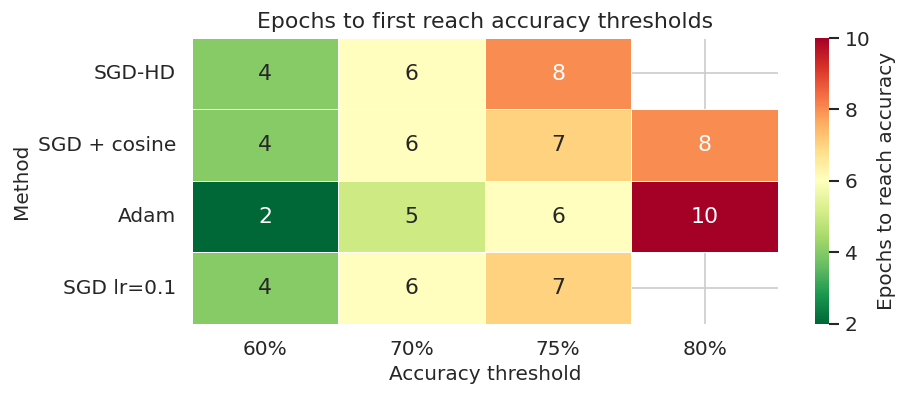

Saved: figures/fig5_convergence_speed.pdf


In [ ]:
def epochs_to_threshold(val_acc_list, threshold):
    """
    Returns the first epoch index (1-based) at which validation accuracy
    exceeds `threshold`. Returns None if never reached.
    """
    for epoch, acc in enumerate(val_acc_list, start=1):
        if acc >= threshold:
            return epoch
    return None


thresholds = [0.60, 0.70, 0.75, 0.80]
methods_to_compare = ["SGD-HD", "SGD + cosine", "Adam", "SGD lr=0.1"]

table_data = {}
for method in methods_to_compare:
    if method not in all_results:
        continue
    val_accs = all_results[method]["val_acc"]
    table_data[method] = [
        epochs_to_threshold(val_accs, thr) for thr in thresholds
    ]


print(f"{'Method':<20}  " + "  ".join([f"{int(t*100)}% acc" for t in thresholds]))
print("-" * 60)
for method, values in table_data.items():
    row = "  ".join([f"{v:>8}" if v else f"{'  —':>8}" for v in values])
    print(f"{method:<20}  {row}")

df = pd.DataFrame(table_data, index=[f"{int(t*100)}%" for t in thresholds]).T

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(df.astype(float), annot=True, fmt=".0f", cmap="RdYlGn_r",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Epochs to reach accuracy"})
ax.set_title("Epochs to first reach accuracy thresholds")
ax.set_xlabel("Accuracy threshold")
ax.set_ylabel("Method")
plt.tight_layout()
plt.savefig("figures/fig5_convergence_speed.pdf", bbox_inches="tight")
plt.show()
print("Saved: figures/fig5_convergence_speed.pdf")

# Plot: Effect of meta learning rate β

SGD-HD β=1e-08: 100%|██████████| 10/10 [07:08<00:00, 42.87s/it, lr=1.00e-01, tr_loss=0.568, vl_acc=76.6%]


  [SGD-HD β=1e-08] Final test accuracy: 77.34%


SGD-HD β=1e-07: 100%|██████████| 10/10 [07:08<00:00, 42.87s/it, lr=1.00e-01, tr_loss=0.516, vl_acc=79.7%]


  [SGD-HD β=1e-07] Final test accuracy: 80.01%


SGD-HD β=1e-06: 100%|██████████| 10/10 [07:09<00:00, 42.91s/it, lr=1.00e-01, tr_loss=0.534, vl_acc=78.5%]


  [SGD-HD β=1e-06] Final test accuracy: 79.71%


SGD-HD β=1e-05: 100%|██████████| 10/10 [07:08<00:00, 42.83s/it, lr=1.04e-01, tr_loss=0.514, vl_acc=78.0%]


  [SGD-HD β=1e-05] Final test accuracy: 77.68%


SGD-HD β=1e-04: 100%|██████████| 10/10 [07:09<00:00, 42.93s/it, lr=1.39e-01, tr_loss=0.556, vl_acc=73.8%]


  [SGD-HD β=1e-04] Final test accuracy: 73.95%


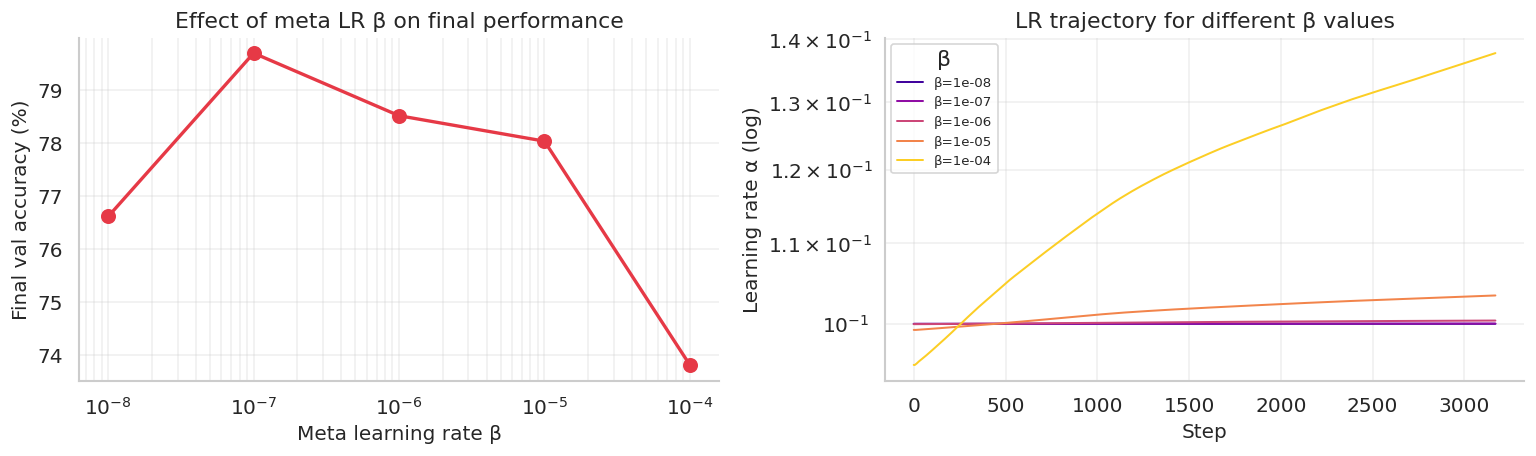

Saved: figures/fig6_meta_lr_ablation.pdf


In [ ]:
meta_lr_values = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
meta_lr_results = {}

_loaded_meta = load_results_if_exist(METALR_PATH)
if _loaded_meta:
    meta_lr_results.update(_loaded_meta)
    print(f" Already available : {list(meta_lr_results.keys())}")

for beta in meta_lr_values:
    label = f"SGD-HD β={beta:.0e}"

    def make_hgd_ablation(model, _beta=beta):
        return SGDHD(
            model.parameters(),
            lr=CONFIG["hgd_lr_init"],
            meta_lr=_beta,
            momentum=CONFIG["hgd_momentum"],
            weight_decay=CONFIG["weight_decay"],
            lr_clip=CONFIG["hgd_lr_clip"],
        )

    if label in meta_lr_results:
        print(f" {label} already computed.")
        continue
    res = run_experiment(label, make_hgd_ablation)
    save_experiment_result(label, res, meta_lr_results, METALR_PATH)

# Plot final val accuracy vs beta
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

final_accs_beta = [meta_lr_results[f"SGD-HD β={b:.0e}"]["val_acc"][-1] * 100
                   for b in meta_lr_values]
axes[0].semilogx(meta_lr_values, final_accs_beta, "o-", color="#e63946", lw=2, markersize=8)
axes[0].set_xlabel("Meta learning rate β")
axes[0].set_ylabel("Final val accuracy (%)")
axes[0].set_title("Effect of meta LR β on final performance")
axes[0].grid(True, which="both", alpha=0.3)

# LR trajectories for different β values
cmap_vals = plt.cm.plasma(np.linspace(0.1, 0.9, len(meta_lr_values)))
for (label, res), color in zip(meta_lr_results.items(), cmap_vals):
    lr_hist = np.array(res["lr_history"])
    if len(lr_hist) > CONFIG["num_epochs"] * 2:
        window = max(1, len(train_loader))
        kernel = np.ones(window) / window
        lr_hist = np.convolve(lr_hist, kernel, mode="valid")
    axes[1].plot(lr_hist, lw=1.2, color=color, label=label.split(" ")[-1])

axes[1].set_yscale("log")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Learning rate α (log)")
axes[1].set_title("LR trajectory for different β values")
axes[1].legend(title="β", fontsize=8)
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/fig6_meta_lr_ablation.pdf", bbox_inches="tight")
plt.show()
print("Saved: figures/fig6_meta_lr_ablation.pdf")

#  Quantitative summary table

In [ ]:
print("=" * 85)
print(f"{'Method':<25} {'Train Loss':>10} {'Val Acc':>10} {'Test Acc':>10} {'Best Val':>10}")
print("=" * 85)

for name, res in sorted(all_results.items(),
                         key=lambda x: x[1]["test_acc"], reverse=True):
    train_loss = res["train_loss"][-1]
    val_acc    = res["val_acc"][-1]  * 100
    test_acc   = res["test_acc"]     * 100
    best_val   = max(res["val_acc"]) * 100
    print(f"{name:<25} {train_loss:>10.4f} {val_acc:>9.2f}% {test_acc:>9.2f}% {best_val:>9.2f}%")

print("=" * 85)
print("\nNote: test accuracy evaluated once at the end of training.")
print("      Best val accuracy is the maximum across all epochs.")

Method                    Train Loss    Val Acc   Test Acc   Best Val
SGD + cosine                  0.3513     85.12%     86.08%     85.12%
SGD lr=0.01                   0.4152     81.90%     83.23%     81.90%
Adam                          0.4533     82.58%     83.10%     82.58%
SGD lr=0.1                    0.5351     79.30%     80.42%     79.30%
SGD-HD                        0.5343     78.52%     79.71%     79.12%
SGD lr=0.001                  0.9009     66.46%     67.79%     66.46%
SGD lr=0.5                    0.8864     50.98%     52.99%     57.82%

Note: test accuracy evaluated once at the end of training.
      Best val accuracy is the maximum across all epochs.


# Save all results to disk

In [ ]:
import json

def results_to_dict(results_dict):
    out = {}
    for name, res in results_dict.items():
        out[name] = {
            "train_loss": res["train_loss"],
            "train_acc":  res["train_acc"],
            "val_loss":   res["val_loss"],
            "val_acc":    res["val_acc"],
            "test_acc":   float(res["test_acc"]),
            "lr_history": [float(x) for x in res["lr_history"]],
        }
    return out

save_data = {
    "main_results":        results_to_dict(all_results),
    "sensitivity_results": results_to_dict(sensitivity_results),
    "meta_lr_results":     results_to_dict(meta_lr_results),
    "config":              {k: str(v) for k, v in CONFIG.items()},
    "seed":                SEED,
}

with open("figures/all_results.json", "w") as f:
    json.dump(save_data, f, indent=2)

print("Results saved to figures/all_results.json")
print("Figures saved to figures/fig*.pdf")

Results saved to figures/all_results.json
Figures saved to figures/fig*.pdf
